In [17]:
import h5py
import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial
from scipy.optimize import curve_fit

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader  # Make sure these are imported

from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV

from HubbardTweezer.Hubbard.lattice import sqr_lattice

def get_neighbors(grid_size, edges):
    # For each edge, find the index of the neighbors
    grid_width, grid_height = grid_size

    # Helper function to get the row and column from vertex index
    def get_row_col(vertex, width):
        return vertex // width, vertex % width

    def get_idx(role, col, grid_width):
        return role * grid_width + col

    # Initialize the count array
    neighbor_counts = []
    other_neighbor = []

    for edge in edges:
        count = 0
        neighbor = []

        # Get row and column for both vertices
        row, col = get_row_col(edge, grid_width)

        # Determine the edge orientation and count neighbors
        if np.diff(row):  # Horizontal (x) edge
            # Check left and right neighbors
            row.sort()
            if row[0] > 0:
                neighbor.append(
                    [
                        get_idx(row[0], col[0], grid_width),
                        get_idx(row[0] - 1, col[0], grid_width),
                    ]
                )
                count += 1
            if row[1] < grid_height - 1:
                neighbor.append(
                    [
                        get_idx(row[1], col[1], grid_width),
                        get_idx(row[1] + 1, col[1], grid_width),
                    ]
                )
                count += 1
        elif np.diff(col):  # Vertical (y) edge
            # Check top and bottom neighbors
            col.sort()
            if col[0] > 0:
                neighbor.append(
                    [
                        get_idx(row[0], col[0], grid_width),
                        get_idx(row[0], col[0] - 1, grid_width),
                    ]
                )
                count += 1
            if col[1] < grid_width - 1:
                neighbor.append(
                    [
                        get_idx(row[1], col[1], grid_width),
                        get_idx(row[1], col[1] + 1, grid_width),
                    ]
                )
                count += 1
        neighbor_counts.append(count)
        other_neighbor.append(neighbor)
    return np.array(neighbor_counts), other_neighbor

# Custom Model for Exponential Fitting (user-provided)
class ExponentialModel(nn.Module):
    def __init__(self):
        super(ExponentialModel, self).__init__()
        # Initialize parameters a0, a1, b0, b1
        self.a_params = nn.Parameter(
            torch.tensor([-1, -10], dtype=torch.float64)
        )  # For a0, a1
        self.b_params = nn.Parameter(
            torch.tensor([1, 10], dtype=torch.float64)
        )  # For b0, b1

    def forward(self, x_input_dict):
        # x_input_dict is expected to have "rij" and "d" keys
        # Assuming x_input_dict["d"] and x_input_dict["rij"] are per-sample tensors (e.g., shape [N] or [N,1])
        # a_effective = a0*d + a1
        # b_effective = b0*d + b1
        # result = exp(a_effective * rij + b_effective)

        # Ensure operations are element-wise if inputs are 1D tensors per sample
        # If x_input_dict["d"] is shape (N,) or (N,1)
        a_eff = self.a_params[0] * x_input_dict["d"] + self.a_params[1]
        b_eff = self.b_params[0] * x_input_dict["d"] + self.b_params[1]

        return torch.exp(a_eff * x_input_dict["rij"] + b_eff)


# Helper function for the MSE loss criterion used in LBFGS optimization
def mse_criterion_for_lbfgs(outputs, targets):
    mse_loss_fn = nn.MSELoss()  # Averages over all elements
    # targets might be (B, P, 1). torch.var computes variance over all elements.
    var_targets_val = torch.var(targets)
    loss = mse_loss_fn(outputs, targets) / (
        var_targets_val.item() if var_targets_val.item() != 0 else 1.0
    )
    return loss


# Helper function for R2 Score Evaluation
def R2_eval_metric(model: nn.Module, X_data_dict, Y_data_tensor):
    model.eval()
    with torch.no_grad():
        predictions = model(X_data_dict)

    # Flatten to compute metrics over all individual data points (N*P)
    Y_data_flat = Y_data_tensor.reshape(-1)
    predictions_flat = predictions.reshape(-1)

    sst = torch.var(Y_data_flat)
    if sst.item() == 0:
        return -float("inf")

    ssr = torch.mean((Y_data_flat - predictions_flat) ** 2)
    r2 = 1 - (ssr / sst)
    return r2.item()


def train_fold_with_lbfgs_refined(
    model_instance, train_X_dict, train_Y_tensor, l1_lambda, lbfgs_params
):
    model_instance.train()
    optimizer = optim.LBFGS(
        model_instance.parameters(),
        lr=lbfgs_params.get("lr", 0.005),
        max_iter=lbfgs_params.get("max_iter_per_step", 20),
        tolerance_grad=lbfgs_params.get("tol_grad", 1e-7),
        tolerance_change=lbfgs_params.get("tol_change", 1e-9),
        history_size=lbfgs_params.get("history_size", 100),
    )

    def closure():
        optimizer.zero_grad()
        outputs = model_instance(train_X_dict)
        data_loss = mse_criterion_for_lbfgs(outputs, train_Y_tensor)

        l1_penalty_val = 0.0
        if l1_lambda > 0:
            for param in model_instance.parameters():
                l1_penalty_val += torch.abs(param.reshape(-1)).sum()

        total_loss = data_loss + l1_lambda * l1_penalty_val
        total_loss.backward()
        return total_loss

    num_epochs = lbfgs_params.get("epochs", 50)
    tol_loss_change = lbfgs_params.get("tol_loss_change", 1e-9)
    loss_old = torch.inf

    for epoch in range(num_epochs):
        loss_new = optimizer.step(closure)
        if loss_new is None:  # Should not happen
            print("Warning: LBFGS step returned None in fold training.")
            break
        current_loss_val = loss_new.item()
        if abs(loss_old - current_loss_val) < tol_loss_change and epoch > 0:
            break
        loss_old = current_loss_val
    return model_instance


def cross_validate_lbfgs_refined(
    model_class,
    full_X_torch_dict,
    full_Y_torch_tensor,
    l1_lambdas,
    k_folds=5,
    lbfgs_params_cv=None,
    device="cpu",
):
    if lbfgs_params_cv is None:
        lbfgs_params_cv = {
            "lr": 0.005,
            "max_iter_per_step": 20,
            "epochs": 50,
            "tol_grad": 1e-7,
            "tol_change": 1e-9,
            "tol_loss_change": 1e-9,
        }

    # KFold splits along the first dimension of the tensors
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    # full_Y_torch_tensor has shape (N, P, F_y), indices are for N
    indices = torch.arange(full_Y_torch_tensor.shape[0])

    avg_val_r2_scores_per_lambda = []
    print("Starting Cross-Validation...")

    for l1_lambda in l1_lambdas:
        fold_specific_val_r2_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(indices)):
            # train_idx and val_idx select from the first dimension (N)
            train_X_fold_dict = {
                key: full_X_torch_dict[key][train_idx].to(device)
                for key in full_X_torch_dict
            }
            train_Y_fold_tensor = full_Y_torch_tensor[train_idx].to(device)

            val_X_fold_dict = {
                key: full_X_torch_dict[key][val_idx].to(device)
                for key in full_X_torch_dict
            }
            val_Y_fold_tensor = full_Y_torch_tensor[val_idx].to(device)

            current_model_instance = model_class().to(device)
            if hasattr(current_model_instance, "double"):
                current_model_instance.double()

            train_fold_with_lbfgs_refined(
                model_instance=current_model_instance,
                train_X_dict=train_X_fold_dict,
                train_Y_tensor=train_Y_fold_tensor,
                l1_lambda=l1_lambda,
                lbfgs_params=lbfgs_params_cv,
            )

            val_r2 = R2_eval_metric(
                current_model_instance, val_X_fold_dict, val_Y_fold_tensor
            )
            fold_specific_val_r2_scores.append(val_r2)

        avg_r2_for_this_lambda = (
            np.mean(fold_specific_val_r2_scores)
            if fold_specific_val_r2_scores
            else -float("inf")
        )
        avg_val_r2_scores_per_lambda.append(avg_r2_for_this_lambda)
        print(
            f"  L1 Lambda: {l1_lambda:.3e} -> Avg Validation R2: {avg_r2_for_this_lambda:.4f}"
        )

    if not avg_val_r2_scores_per_lambda:
        print("Warning: No validation scores recorded.")
        return l1_lambdas[0] if l1_lambdas else 0.0, []

    best_lambda_idx = np.argmax(avg_val_r2_scores_per_lambda)
    best_l1_lambda = l1_lambdas[best_lambda_idx]

    print(
        f"\nBest L1 lambda from CV: {best_l1_lambda:.3e} (Avg R2: {avg_val_r2_scores_per_lambda[best_lambda_idx]:.4f})"
    )
    return best_l1_lambda, avg_val_r2_scores_per_lambda


def train_final_model_lbfgs(
    model_class,
    full_X_torch_dict,
    full_Y_torch_tensor,
    best_l1_lambda,
    final_lbfgs_params=None,
    device="cpu",
):
    if final_lbfgs_params is None:
        final_lbfgs_params = {
            "lr": 0.005,
            "max_iter_per_step": 50,
            "epochs": 200,
            "tol_grad": 1e-9,
            "tol_change": 1e-11,
            "tol_loss_change": 1e-11,
        }

    print(f"\nTraining final model with best L1 lambda: {best_l1_lambda:.3e}")
    final_model_instance = model_class().to(device)
    if hasattr(final_model_instance, "double"):
        final_model_instance.double()

    X_data_device_dict = {
        key: full_X_torch_dict[key].to(device) for key in full_X_torch_dict
    }
    Y_data_device_tensor = full_Y_torch_tensor.to(device)

    trained_final_model = train_fold_with_lbfgs_refined(
        model_instance=final_model_instance,
        train_X_dict=X_data_device_dict,
        train_Y_tensor=Y_data_device_tensor,
        l1_lambda=best_l1_lambda,
        lbfgs_params=final_lbfgs_params,
    )

    trained_final_model.eval()
    with torch.no_grad():
        predictions = trained_final_model(X_data_device_dict)
        final_loss_mse_part = mse_criterion_for_lbfgs(predictions, Y_data_device_tensor)

        l1_penalty_val = 0.0
        if best_l1_lambda > 0:
            for param in trained_final_model.parameters():
                l1_penalty_val += torch.abs(param.reshape(-1)).sum()
        total_final_loss = final_loss_mse_part + best_l1_lambda * l1_penalty_val
        final_r2 = R2_eval_metric(
            trained_final_model, X_data_device_dict, Y_data_device_tensor
        )

    print(f"Final model training finished.")
    print(f"  Parameters (a_params): {trained_final_model.a_params.data.cpu().numpy()}")
    print(f"  Parameters (b_params): {trained_final_model.b_params.data.cpu().numpy()}")
    print(f"  Final Model Total Loss (MSE_norm + L1): {total_final_loss.item():.6f}")
    print(f"  Final Model Normalized MSE part: {final_loss_mse_part.item():.6f}")
    print(f"  Final Model R2 on all data: {final_r2:.4f}")
    return trained_final_model

# 4x4

In [19]:
L = 4
grid = [L, L]
with h5py.File(f"{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array(grid))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

X = nnr[mask]
Y = nnt[mask]

# Example Usage
grid = [L, L]
edges = links

neighbor_counts, other_neighbor = get_neighbors(grid, edges)
for i in range(len(edges)):
    print(f"Edge {i}: {edges[i]} neighbors: {neighbor_counts[i]} {other_neighbor[i]}")


3003
1187
Edge 0: [0 1] neighbors: 1 [[np.int64(1), np.int64(2)]]
Edge 1: [1 2] neighbors: 2 [[np.int64(1), np.int64(0)], [np.int64(2), np.int64(3)]]
Edge 2: [2 3] neighbors: 1 [[np.int64(2), np.int64(1)]]
Edge 3: [0 4] neighbors: 1 [[np.int64(4), np.int64(8)]]
Edge 4: [1 5] neighbors: 1 [[np.int64(5), np.int64(9)]]
Edge 5: [4 5] neighbors: 1 [[np.int64(5), np.int64(6)]]
Edge 6: [2 6] neighbors: 1 [[np.int64(6), np.int64(10)]]
Edge 7: [5 6] neighbors: 2 [[np.int64(5), np.int64(4)], [np.int64(6), np.int64(7)]]
Edge 8: [3 7] neighbors: 1 [[np.int64(7), np.int64(11)]]
Edge 9: [6 7] neighbors: 1 [[np.int64(6), np.int64(5)]]
Edge 10: [4 8] neighbors: 2 [[np.int64(4), np.int64(0)], [np.int64(8), np.int64(12)]]
Edge 11: [5 9] neighbors: 2 [[np.int64(5), np.int64(1)], [np.int64(9), np.int64(13)]]
Edge 12: [8 9] neighbors: 1 [[np.int64(9), np.int64(10)]]
Edge 13: [ 6 10] neighbors: 2 [[np.int64(6), np.int64(2)], [np.int64(10), np.int64(14)]]
Edge 14: [ 9 10] neighbors: 2 [[np.int64(9), np.int64

In [20]:
# Data dimensions: (N, P, F)
# N: Number of main samples (e.g., systems, experiments)
# P: Number of pairs (data points) within each main sample
# F: Feature dimension (assumed to be 1 for rij and d in this model's formula)

# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["d"] = (
    torch.tensor(neighbor_counts, dtype=torch.float64)
    .unsqueeze(0)
    .repeat(X_torch["rij"].shape[0], 1)
)  # Ensure d is broadcastable to match rij shape
Y_torch = torch.tensor(Y, dtype=torch.float64)

num_main_samples = Y_torch.shape[0]  # N: e.g., 50 different experimental setups
num_pairs_per_sample = Y_torch.shape[1]  # P: e.g., 10 (rij,d) pairs within each setup
rij_dim = X_torch["rij"].shape[-1]  # F: Feature dimension for rij
d_dim = X_torch["d"].shape[-1]  # F: Feature dimension for d

device = "cpu"
print(f"Using device: {device}")

# Data does not need to be moved to device here if functions handle it,
# but good practice to do it once if all data fits.
# My functions move data to device per fold/run.

l1_lambdas_to_try = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
cv_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 25,
    "epochs": 25,
    "tol_grad": 1e-6,
    "tol_change": 1e-8,
    "tol_loss_change": 1e-8,
}

best_lambda, cv_scores = cross_validate_lbfgs_refined(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    l1_lambdas=l1_lambdas_to_try,
    k_folds=3,  # Use 3-5 folds for CV
    lbfgs_params_cv=cv_lbfgs_params,
    device=device,
)

final_train_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 40,
    "epochs": 100,
    "tol_grad": 1e-8,
    "tol_change": 1e-10,
    "tol_loss_change": 1e-10,
}

final_trained_model = train_final_model_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    best_l1_lambda=best_lambda,
    final_lbfgs_params=final_train_lbfgs_params,
    device=device,
)

learned_a = final_trained_model.a_params.data.cpu().numpy()
learned_b = final_trained_model.b_params.data.cpu().numpy()
print(f"\nLearned Exponential model equation (approx log(Y)):")
print(
    f"  ({learned_a[0]:.4f} * d + {learned_a[1]:.4f}) * X_rij + ({learned_b[0]:.4f} * d + {learned_b[1]:.4f})"
)

Using device: cpu
Starting Cross-Validation...
  L1 Lambda: 0.000e+00 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-06 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-05 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-04 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-03 -> Avg Validation R2: 0.9432

Best L1 lambda from CV: 1.000e-05 (Avg R2: 0.9905)

Training final model with best L1 lambda: 1.000e-05
Final model training finished.
  Parameters (a_params): [-0.34487818 -6.85145846]
  Parameters (b_params): [0.40888647 9.30687211]
  Final Model Total Loss (MSE_norm + L1): 0.008634
  Final Model Normalized MSE part: 0.008465
  Final Model R2 on all data: 0.9915

Learned Exponential model equation (approx log(Y)):
  (-0.3449 * d + -6.8515) * X_rij + (0.4089 * d + 9.3069)


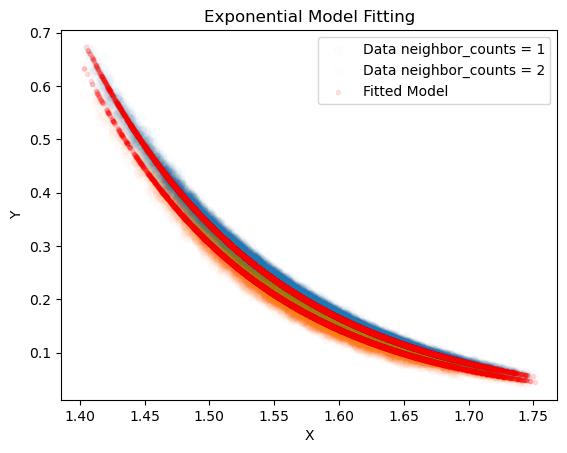

In [21]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = final_trained_model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_63602/2242393529.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_63602/2242393529.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.009507034075577122kHz')

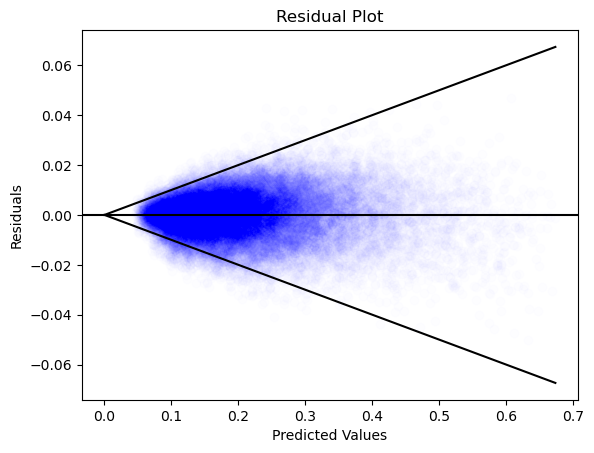

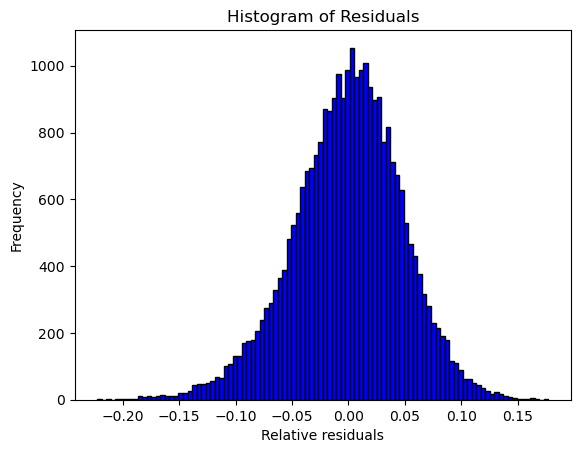

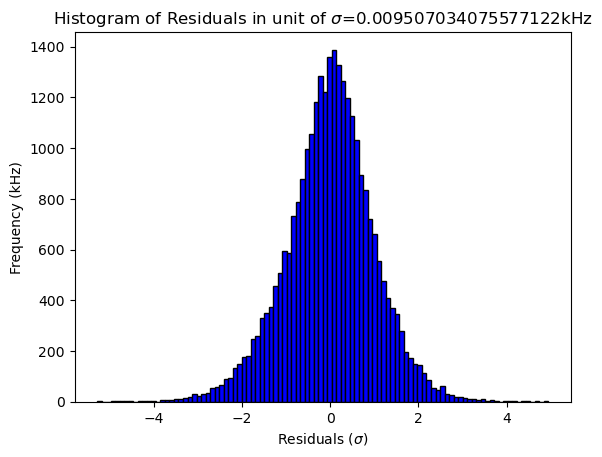

In [22]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(final_trained_model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

# 5x5

In [16]:
L = 5
grid = [L, L]
with h5py.File(f"{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array(grid))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

X = nnr[mask]
Y = nnt[mask]

# Example Usage
grid = [L, L]
edges = links

neighbor_counts, other_neighbor = get_neighbors(grid, edges)
for i in range(len(edges)):
    print(f"Edge {i}: {edges[i]} neighbors: {neighbor_counts[i]} {other_neighbor[i]}")


1000
302
Edge 0: [0 1] neighbors: 1 [[np.int64(1), np.int64(2)]]
Edge 1: [1 2] neighbors: 2 [[np.int64(1), np.int64(0)], [np.int64(2), np.int64(3)]]
Edge 2: [2 3] neighbors: 2 [[np.int64(2), np.int64(1)], [np.int64(3), np.int64(4)]]
Edge 3: [3 4] neighbors: 1 [[np.int64(3), np.int64(2)]]
Edge 4: [0 5] neighbors: 1 [[np.int64(5), np.int64(10)]]
Edge 5: [1 6] neighbors: 1 [[np.int64(6), np.int64(11)]]
Edge 6: [5 6] neighbors: 1 [[np.int64(6), np.int64(7)]]
Edge 7: [2 7] neighbors: 1 [[np.int64(7), np.int64(12)]]
Edge 8: [6 7] neighbors: 2 [[np.int64(6), np.int64(5)], [np.int64(7), np.int64(8)]]
Edge 9: [3 8] neighbors: 1 [[np.int64(8), np.int64(13)]]
Edge 10: [7 8] neighbors: 2 [[np.int64(7), np.int64(6)], [np.int64(8), np.int64(9)]]
Edge 11: [4 9] neighbors: 1 [[np.int64(9), np.int64(14)]]
Edge 12: [8 9] neighbors: 1 [[np.int64(8), np.int64(7)]]
Edge 13: [ 5 10] neighbors: 2 [[np.int64(5), np.int64(0)], [np.int64(10), np.int64(15)]]
Edge 14: [ 6 11] neighbors: 2 [[np.int64(6), np.int64(

In [18]:
# Data dimensions: (N, P, F)
# N: Number of main samples (e.g., systems, experiments)
# P: Number of pairs (data points) within each main sample
# F: Feature dimension (assumed to be 1 for rij and d in this model's formula)

# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["d"] = (
    torch.tensor(neighbor_counts, dtype=torch.float64)
    .unsqueeze(0)
    .repeat(X_torch["rij"].shape[0], 1)
)  # Ensure d is broadcastable to match rij shape
Y_torch = torch.tensor(Y, dtype=torch.float64)

num_main_samples = Y_torch.shape[0]  # N: e.g., 50 different experimental setups
num_pairs_per_sample = Y_torch.shape[1]  # P: e.g., 10 (rij,d) pairs within each setup
rij_dim = X_torch["rij"].shape[-1]  # F: Feature dimension for rij
d_dim = X_torch["d"].shape[-1]  # F: Feature dimension for d

device = "cpu"
print(f"Using device: {device}")

# Data does not need to be moved to device here if functions handle it,
# but good practice to do it once if all data fits.
# My functions move data to device per fold/run.

l1_lambdas_to_try = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
cv_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 25,
    "epochs": 25,
    "tol_grad": 1e-6,
    "tol_change": 1e-8,
    "tol_loss_change": 1e-8,
}

best_lambda, cv_scores = cross_validate_lbfgs_refined(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    l1_lambdas=l1_lambdas_to_try,
    k_folds=3,  # Use 3-5 folds for CV
    lbfgs_params_cv=cv_lbfgs_params,
    device=device,
)

final_train_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 40,
    "epochs": 100,
    "tol_grad": 1e-8,
    "tol_change": 1e-10,
    "tol_loss_change": 1e-10,
}

final_trained_model = train_final_model_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    best_l1_lambda=best_lambda,
    final_lbfgs_params=final_train_lbfgs_params,
    device=device,
)

learned_a = final_trained_model.a_params.data.cpu().numpy()
learned_b = final_trained_model.b_params.data.cpu().numpy()
print(f"\nLearned Exponential model equation (approx log(Y)):")
print(
    f"  ({learned_a[0]:.4f} * d + {learned_a[1]:.4f}) * X_rij + ({learned_b[0]:.4f} * d + {learned_b[1]:.4f})"
)

Using device: cpu
Starting Cross-Validation...
  L1 Lambda: 0.000e+00 -> Avg Validation R2: 0.9885
  L1 Lambda: 1.000e-06 -> Avg Validation R2: 0.9505
  L1 Lambda: 1.000e-05 -> Avg Validation R2: 0.9899
  L1 Lambda: 1.000e-04 -> Avg Validation R2: 0.5988
  L1 Lambda: 1.000e-03 -> Avg Validation R2: 0.9903

Best L1 lambda from CV: 1.000e-03 (Avg R2: 0.9903)

Training final model with best L1 lambda: 1.000e-03
Final model training finished.
  Parameters (a_params): [-0.46986123 -6.59317589]
  Parameters (b_params): [0.60139011 8.90845447]
  Final Model Total Loss (MSE_norm + L1): 0.025935
  Final Model Normalized MSE part: 0.009362
  Final Model R2 on all data: 0.9906

Learned Exponential model equation (approx log(Y)):
  (-0.4699 * d + -6.5932) * X_rij + (0.6014 * d + 8.9085)


Parameters are close to the 4x4 case. Mixed size training might do the trick.

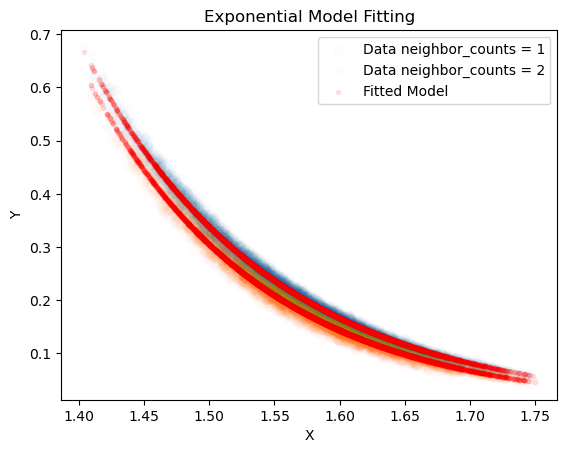

In [13]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = final_trained_model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_63602/2242393529.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_63602/2242393529.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.009825260160671097kHz')

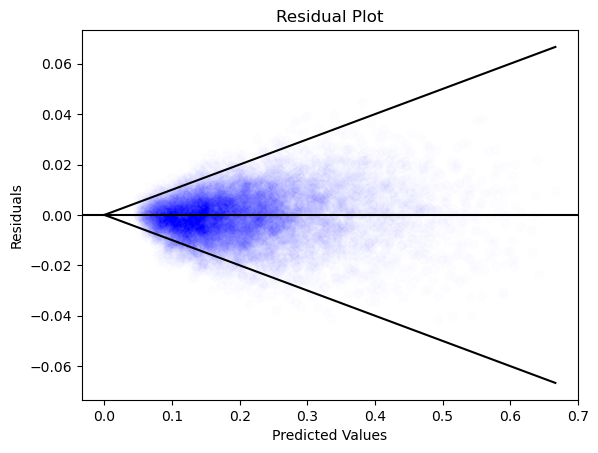

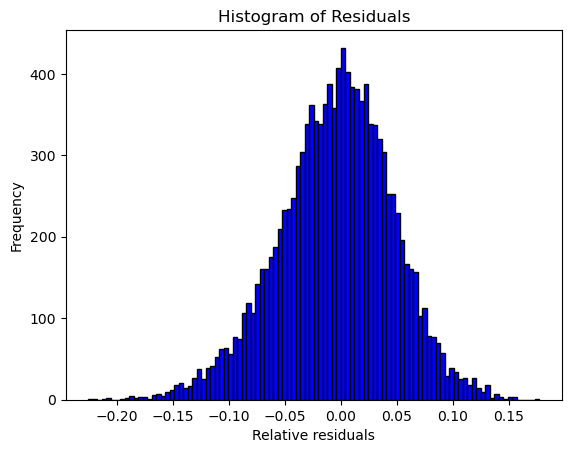

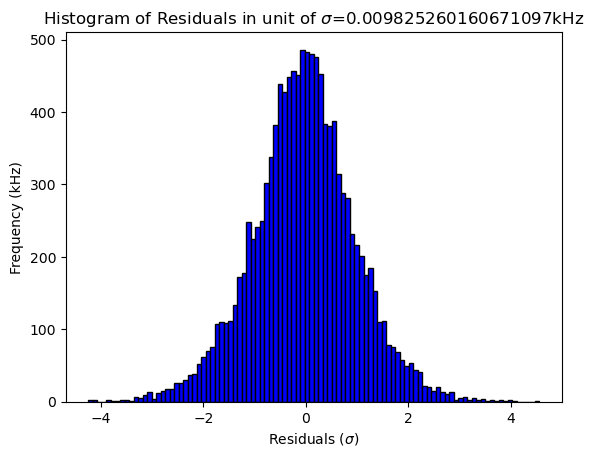

In [14]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(final_trained_model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")